## <span style="color:green"><h1><center>Probabilistic Flood Inundation Mapping using Physics-Aware Spatial AI</center></h1></span>
<center>Prepared by <br>
    <b>Jibin Joseph and Venkatesh Merwade</b><br> 
Lyles School of Civil and Construction Engineering, Purdue University<br>
joseph57@purdue.edu, vmerwade@purdue.edu<br>
<b><br>
    FAIR Science in Water Resources</b><br></center>

# <span style="color:green">General Outline</span>

This notebook is created to demonstrate FiLM-conditioned U-Net inference for generating high-resolution flood inundation maps from terrain, discharge, and seasonal inputs. The outline of the notebook is listed below:

1. Introduction  
2. Data Description  
3. Model Overview  
4. Python Workflow
   - 4.1 Import the packages and download the data
   - 4.2 Utility Functions
   - 4.3 User Settings
   - 4.4 Dataset Class
   - 4.5 FiLM U-Net Model
   - 4.6 Load Dataset and Checkpoint
   - 4.7 Prediction Function & Save Prediction as GeoTIFF
   - 4.8 Scenario A: Option 1 — DEM + Discharge
   - 4.9 Scenario B: Option 2 — DEM + Discharge + Season
   - 4.10 IoU Comparison Across Discharge Scenarios
5. Discussion and Summary  

## <span style="color:green">1. Introduction</span>
Flood disasters are increasing in both frequency and societal impact across the United States and globally. Despite advances in hydrologic monitoring, reliable and high-resolution flood inundation maps remain sparse, particularly in ungauged or poorly instrumented river reaches. Traditional physics-based hydrodynamic models, while accurate, are often computationally intensive and difficult to scale for rapid, large-area applications. This challenge introduces a Spatial AI-driven approach that leverages deep learning and remote sensing to learn the relationships between hydrologic forcing, terrain controls, and observed flood extent. By integrating multi-source geospatial data, the framework aims to generate high-resolution (10 m), probabilistic flood inundation maps that are both scalable and computationally efficient.

The dataset combines:
<ol type="a">
<strong><span style="color:green"><li> Hydrologic forcing (discharge records),</li></span></strong>
<strong><span style="color:green"><li> Topographic information from Digital Elevation Models (DEMs),</li></span></strong>
<strong><span style="color:green"><li> Remotely sensed surface water observations derived from Sentinel-2 imagery.</li></span></strong>
</ol>

These inputs are fused into an AI-ready dataset representing diverse flood events across selected river reaches in the United States.

A physics-aware convolutional neural network is then used to model the system. Rather than explicitly solving hydrodynamic equations, the model learns physically meaningful relationships from data, enabling it to:

<ol type="a">
<strong><span style="color:green"><li> Ingest static spatial layers and a target discharge,</li></span></strong>
<strong><span style="color:green"><li> Predict pixel-wise flood probability, and</li></span></strong>
<strong><span style="color:green"><li> Generate corresponding binary inundation maps.</li></span></strong>
</ol>

Importantly, this framework emphasizes probabilistic outputs and uncertainty awareness, supporting more transparent and interpretable flood predictions. The resulting system is designed to be rapid, reusable across basins, and adaptable to new flood scenarios, making it well-suited for real-time applications and large-scale flood risk assessment.

## <span style="color:green">2. Data Description</span>
This challenge dataset is developed for a river reach along the Wabash River near a USGS stream gaging station at Lafayette, Indiana. It integrates remotely sensed flood extent, hydrologic observations, terrain information, and seasonal context into a unified, analysis-ready format for Spatial AI modeling. The selected reach represents a well-monitored floodplain system where discharge observations and satellite-derived inundation can be aligned in space and time. This makes it suitable for learning relationships between river flow, terrain, and flood extent.

<ol type="a">

<li>
<strong style="color:green;">Remote Sensing–Derived Inundation Masks</strong>

<div style="margin-left:20px;">

<p>
Flood inundation labels are derived from the Dynamic World product generated from Sentinel-2 imagery (10 m spatial resolution, ~5-day revisit).
</p>

<ul>
  <li>The Dynamic World <strong>“water” class</strong> is extracted and converted into a binary inundation mask:
    <ul>
      <li><strong>1 →</strong> inundated (water/flooded pixel)</li>
      <li><strong>0 →</strong> non-inundated (land pixel)</li>
    </ul>
  </li>
  <li>Cloud-contaminated pixels are filtered during preprocessing to ensure reliable labels. The below image shows the study region, dynamic land cover with different classes and binary inundation masks for a particular day.</li>
</ul>

<p align="center">
  <img src="https://raw.githubusercontent.com/jibcar/inundation_mapping/main/image1.jpg" width="500">
</p>

<ul>
  <li>Each mask corresponds to a specific satellite acquisition date, capturing flood conditions under varying discharge scenarios.</li>
  <li>These binary masks serve as <strong>ground truth labels</strong> for training and evaluation of the deep learning model. THESE MASKS ARE STORED IN DW_Filt folder.</li>
</ul>

</div>
</li>

<li>
<strong style="color:green;">Discharge Data (Hydrologic Forcing)</strong>

<div style="margin-left:20px;">

<p>
Discharge values are obtained from the USGS NWIS portal for the corresponding gauging station (USGS 03335500 Wabash River at Lafayette).
</p>

<ul>
  <li>Units: cubic feet per second (cfs)</li>
  <li>Temporal resolution: typically 15-minute to daily observations</li>
  <li>For each satellite image, discharge is matched to the closest timestamp of acquisition</li>
  <li>This provides a flow-conditioned input variable representing hydrologic forcing</li>
</ul>

<p>
Discharge acts as the dynamic driver controlling flood extent in the model.
</p>

</div>
</li>

<li>
<strong style="color:green;">Topographic Data (DEM)</strong>

<div style="margin-left:20px;">

<p>
Terrain information is derived from the USGS National Elevation Dataset (NED).
</p>

<ul>
  <li>Spatial resolution: consistent with or resampled to 10 m</li>
  <li>Provides bare-earth elevation across the study reach</li>
  <li>Used to capture:
    <ul>
      <li>Floodplain structure</li>
      <li>Elevation gradients</li>
      <li>Flow pathways and low-lying areas</li>
    </ul>
  </li>
</ul>

<p>
The DEM represents a static physical constraint on inundation patterns. The DEM data is stored in "static_data" folder
</p>

</div>
</li>

<li>
<strong style="color:green;">Seasonal Information</strong>

<div style="margin-left:20px;">

<p>
Seasonality is derived from the date of satellite image acquisition.
</p>

<ul>
  <li>Each observation is assigned a season:
    <ul>
      <li>Winter (Dec–Feb)</li>
      <li>Spring (Mar–May)</li>
      <li>Summer (Jun–Aug)</li>
      <li>Fall (Sep–Nov)</li>
    </ul>
  </li>
  <li>Encoded as categorical or one-hot features for model input</li>
  <li>Captures hydroclimatic variability:
    <ul>
        <li>It can account seasonal soil moisture condition</li>
      <li>Snowmelt-driven floods (spring)</li>
      <li>Convective storm flooding (summer)</li>
      <li>Baseflow-dominated conditions (fall/winter)</li>
    </ul>
  </li>
</ul>

</div>
</li>

</ol>

## <span style="color:green">3. Model Overview: FiLM-Conditioned U-Net for Flood Inundation</span>

This framework uses a **FiLM-conditioned U-Net** to learn the relationship between terrain, hydrologic forcing, and flood extent from remote sensing data. The model architecture is shown below:

<p align="center">
  <img src="https://raw.githubusercontent.com/jibcar/inundation_mapping/main/image2.jpg" width="1000">
</p>


### <span style="color:green">Core Idea</span>

The model predicts pixel-wise flood probability by combining:

- **Static spatial features**
  - Digital Elevation Model (DEM)

- **Dynamic conditioning variables**
  - normalized discharge  
  - season (one-hot encoded)



### <span style="color:green">Architecture</span>

The model follows an encoder–decoder (U-Net) structure:

- **Encoder**  
  Extracts hierarchical spatial features and captures terrain patterns

- **Bottleneck**  
  Learns compressed spatial representation

- **Decoder**  
  Reconstructs high-resolution inundation maps using skip connections

### <span style="color:green">Skip Connections</span>

Skip connections link corresponding layers between the encoder and decoder.

- Feature maps from the encoder are directly passed to the decoder  
- These features are concatenated with upsampled decoder features  
- This helps recover fine spatial details lost during downsampling  

Role in flood mapping:

- Preserves sharp boundaries of inundation extent  
- Retains terrain-driven spatial patterns such as channels and floodplains  
- Improves localization of water extent at high resolution  

Without skip connections, the model would produce overly smooth and less accurate inundation maps.


## <span style="color:green">FiLM Conditioning</span>

To incorporate physical context, the model uses Feature-wise Linear Modulation (FiLM).

**Conditioning vector:**
- normalized discharge  
- season (one-hot encoded)

For each feature map:
FiLM(x) = x * (1 + γ) + β

where:
- γ scales feature activations  
- β shifts feature activations  

This allows the model to dynamically adapt predictions based on discharge and seasonal conditions.


## <span style="color:green">Input and Output</span>

**Inputs:**
- Static raster stack with dimensions [C, H, W]  
- Conditioning vector with discharge and season  

**Outputs:**
- Probability map with values between 0 and 1  
- Binary inundation mask obtained using a th#reshold  



## <span style="color:green">Modeling Scenarios</span>

**Option 1: DEM + Discharge**  
- Uses terrain and discharge only  
- Simpler configuration  

**Option 2: DEM + Discharge + Season**  
- Includes seasonal information  
- Captures hydroclimatic var
## <span style="color:green">What it does?</span>

The FiLM U-Net functions as a **spatial AI model** that learns how flood extent changes with discharge and environmental conditions, enabling rapid and scalable inundation mapping without hydrodynamic simulations.

## <span style="color:green">4.1 Import the packages and download the data</span>

We need different packages as shown below. It can be either installed using pip method or conda method. The geoai kernel already contains the required packages.

In [1]:
import os
import csv
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import pandas as pd
import matplotlib.pyplot as plt

from urllib.request import urlretrieve
urlretrieve("https://storage.i-guide.io/datasets/f49f395e-e802-4120-bb4a-d63960b9687c/03335500_data.zip","03335500_data.zip")
import zipfile

with zipfile.ZipFile("03335500_data.zip", 'r') as zip_ref:
    zip_ref.extractall("03335500_data_folder")


## <span style="color:green">4.2 Utility Functions</span>


In [2]:
def read_dates_list(path):
    with open(path, "r") as f:
        return [ln.strip() for ln in f if ln.strip()]


def load_discharge_map(csv_path):
    qmap = {}
    smap = {}

    with open(csv_path, "r", newline="") as f:
        rdr = csv.DictReader(f)

        for row in rdr:
            key = row["datetime"]
            qmap[key] = float(row[discharge_col_name])

            season_raw = row.get("season") or row.get("Season") or row.get("SEASON")
            if season_raw is None:
                raise ValueError(f"No season column found for row: {row}")

            smap[key] = season_raw.strip().lower()

    return qmap, smap


def read_tif(path, dtype="float32"):
    with rasterio.open(path) as src:
        arr = src.read(1, masked=False).astype(dtype)
        profile = src.profile.copy()

    return arr, profile


def read_static_stack(static_dir, target_profile):
    if static_dir is None or not os.path.isdir(static_dir):
        return None

    tif_files = sorted([
        fn for fn in os.listdir(static_dir)
        if fn.lower().endswith(".tif")
    ])

    if len(tif_files) == 0:
        return None

    bands = []

    for fn in tif_files:
        path = os.path.join(static_dir, fn)

        with rasterio.open(path) as src:
            if (
                src.height != target_profile["height"]
                or src.width != target_profile["width"]
                or src.transform != target_profile["transform"]
                or src.crs != target_profile["crs"]
            ):
                data = src.read(
                    out_shape=(1, target_profile["height"], target_profile["width"]),
                    resampling=Resampling.bilinear,
                )[0]
            else:
                data = src.read(1)

        data = np.nan_to_num(data, nan=0.0).astype("float32")
        bands.append(data)

    return np.stack(bands, axis=0)

def build_iou_table(selected, scenario_label, model_inputs):
    df = pd.DataFrame([
        {
            "Scenario": scenario_label,
            "Model inputs": model_inputs,
            "Target discharge (cfs)": ev["q_target"],
            "Closest observed discharge (cfs)": round(ev["q_actual"], 0),
            "Season": None if ev["season"] is None else ev["season"].capitalize(),
            "IoU": round(ev["iou"], 3),
        }
        for ev in selected
    ])

    df = df.sort_values("Target discharge (cfs)").reset_index(drop=True)
    return df

## <span style="color:green">4.3 User Settings</span>


In [3]:
# ---------------------------------------------------
# Choose model option
# ---------------------------------------------------
# Option 1: DEM + discharge
# Option 2: DEM + discharge + season

static_data_include = 1   # change to 2 for seasonal model
epochs_chosen = 100

options = {
    1: {
        "name": "usgs13dem",
        "static_dir": "./03335500_data_folder/static_data/",
        "datetime": "20251201_112034",
        "version": 5,
        "base_ch": 64,
    },
    2: {
        "name": "usgs13dem_seasons",
        "static_dir": "./03335500_data_folder/static_data/",
        "datetime": "20251203_175320",
        "version": 6,
        "base_ch": 64,
    },
}

cfg = options[static_data_include]

suffix = cfg["name"]
static_dir = cfg["static_dir"]
datetime_tag = cfg["datetime"]
version = cfg["version"]
base_ch = cfg["base_ch"]

masks_dir = "./03335500_data_folder/DW_Filt/"
discharge_csv = "./03335500_data_folder/datetime_discharge_filtered_manual_with_season.csv"
discharge_col_name = "USGS_discharge_cfs"

dates_all = read_dates_list("./03335500_data_folder/dates_all.txt")

ckpt_path = f"./03335500_data_folder/checkpoints/unet_film_opt{static_data_include}_base{base_ch}_{epochs_chosen}_{datetime_tag}.pt"

print("Checkpoint:", ckpt_path)

Checkpoint: ./03335500_data_folder/checkpoints/unet_film_opt1_base64_100_20251201_112034.pt


## <span style="color:green">4.4 Dataset Class</span>


In [4]:
SEASONS = ["fall", "winter", "spring", "summer"]
SEASON_TO_IDX = {s: i for i, s in enumerate(SEASONS)}

class InundationDataset(Dataset):
    def __init__(self, dates, masks_dir, discharge_csv, static_dir=None):
        self.dates = dates
        self.masks_dir = masks_dir

        self.qmap, self.smap = load_discharge_map(discharge_csv)

        _, profile = read_tif(os.path.join(masks_dir, dates[0]), dtype="uint8")

        self.profile = profile
        self.H = profile["height"]
        self.W = profile["width"]

        self.static = read_static_stack(static_dir, profile)

        qs = np.array([self.qmap[d] for d in dates], dtype="float32")
        self.q_mu = float(np.mean(qs))
        self.q_std = float(np.std(qs) + 1e-6)

        self.num_seasons = len(SEASONS)
        self.cond_dim = 1 + self.num_seasons

    def __len__(self):
        return len(self.dates)

    def __getitem__(self, idx):
        date = self.dates[idx]

        y, _ = read_tif(os.path.join(self.masks_dir, date), dtype="uint8")
        y = (y > 0).astype("float32")

        if self.static is None:
            x = np.zeros((0, self.H, self.W), dtype="float32")
        else:
            x = self.static.copy()

        q_raw = self.qmap[date]
        q_norm = (q_raw - self.q_mu) / self.q_std

        season_str = self.smap[date]

        season_onehot = np.zeros(self.num_seasons, dtype=np.float32)
        season_onehot[SEASON_TO_IDX[season_str]] = 1.0

        cond = np.concatenate([[np.float32(q_norm)], season_onehot]).astype(np.float32)

        return {
            "x": torch.from_numpy(x),
            "y": torch.from_numpy(y),
            "q": torch.tensor(q_norm, dtype=torch.float32),
            "cond": torch.from_numpy(cond),
            "season": season_str,
            "date": date,
        }

## <span style="color:green">4.5 FiLM U-Net Model</span>

In [5]:
def pad_to_match(up, skip):
    diff_y = skip.size(2) - up.size(2)
    diff_x = skip.size(3) - up.size(3)

    return F.pad(
        up,
        [
            diff_x // 2,
            diff_x - diff_x // 2,
            diff_y // 2,
            diff_y - diff_y // 2,
        ],
    )


class FiLM(nn.Module):
    def __init__(self, n_channels, cond_dim):
        super().__init__()
        self.gamma = nn.Linear(cond_dim, n_channels)
        self.beta = nn.Linear(cond_dim, n_channels)

    def forward(self, feat, cond):
        cond = cond.view(cond.size(0), -1)

        gamma = self.gamma(cond).unsqueeze(-1).unsqueeze(-1)
        beta = self.beta(cond).unsqueeze(-1).unsqueeze(-1)

        return feat * (1 + gamma) + beta


class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetFiLM(nn.Module):
    def __init__(self, in_c=0, base=64, cond_dim=5):
        super().__init__()

        c1 = base
        c2 = base * 2
        c3 = base * 4

        self.enc1 = DoubleConv(in_c if in_c > 0 else 1, c1)
        self.film1 = FiLM(c1, cond_dim)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(c1, c2)
        self.film2 = FiLM(c2, cond_dim)
        self.pool2 = nn.MaxPool2d(2)

        self.bott = DoubleConv(c2, c3)
        self.film3 = FiLM(c3, cond_dim)

        self.up2 = nn.ConvTranspose2d(c3, c2, 2, 2)
        self.dec2 = DoubleConv(c2 * 2, c2)

        self.up1 = nn.ConvTranspose2d(c2, c1, 2, 2)
        self.dec1 = DoubleConv(c1 * 2, c1)

        self.out = nn.Conv2d(c1, 1, 1)

    def forward(self, x, cond):
        if x.shape[1] == 0:
            B, _, H, W = x.shape
            x = torch.zeros((B, 1, H, W), device=x.device, dtype=x.dtype)

        c1 = self.film1(self.enc1(x), cond)
        p1 = self.pool1(c1)

        c2 = self.film2(self.enc2(p1), cond)
        p2 = self.pool2(c2)

        b = self.film3(self.bott(p2), cond)

        u2 = self.up2(b)
        u2 = pad_to_match(u2, c2)
        u2 = torch.cat([u2, c2], dim=1)
        u2 = self.dec2(u2)

        u1 = self.up1(u2)
        u1 = pad_to_match(u1, c1)
        u1 = torch.cat([u1, c1], dim=1)
        u1 = self.dec1(u1)

        return self.out(u1)

## <span style="color:green">4.6 Load Dataset and Checkpoint</span>

In [6]:
ds = InundationDataset(
    dates=dates_all,
    masks_dir=masks_dir,
    discharge_csv=discharge_csv,
    static_dir=static_dir,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
state = torch.load(ckpt_path, map_location=device)

in_c = state["in_channels"]
base = state["base"]
cond_dim = state["cond_dim"]

model = UNetFiLM(in_c=in_c, base=base, cond_dim=cond_dim).to(device)
model.load_state_dict(state["model"])
model.eval()

q_mu = state["q_mu"]
q_std = state["q_std"]
thr = state.get("thr", 0.5)

print("Model loaded successfully")
print("Input channels:", in_c)
print("Base channels:", base)
print("Condition dimension:", cond_dim)
print("Threshold:", thr)
print("q_mu:", q_mu)
print("q_std:", q_std)

Model loaded successfully
Input channels: 1
Base channels: 64
Condition dimension: 5
Threshold: 0.3
q_mu: 6335.4677734375
q_std: 6908.8603525625


/tmp/ipykernel_2060/4175639591.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


## <span style="color:green">4.7 Prediction Function & Save Prediction as GeoTIFF</span>

In [7]:
def predict_for_discharge(
    model,
    ds,
    state,
    q_star,
    season=None,
    threshold=None,
    device="cpu",
):
    model.eval()

    if threshold is None:
        threshold = state.get("thr", 0.5)

    q_mu = state["q_mu"]
    q_std = state["q_std"]
    q_norm = (q_star - q_mu) / q_std

    sample = ds[0]

    x = sample["x"].unsqueeze(0).to(device)
    cond = sample["cond"].unsqueeze(0).to(device).clone()

    cond[:, 0] = q_norm

    if season is not None:
        cond[:, 1:] = 0
        season_idx = SEASON_TO_IDX[season.lower()]
        cond[:, 1 + season_idx] = 1

    with torch.no_grad():
        logits = model(x, cond)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()

    mask = (prob >= threshold).astype("uint8")

    return prob, mask

In [8]:
def save_prediction(prob, mask, state, out_prob_path, out_mask_path):
    profile = state["profile"].copy()

    prob_profile = profile.copy()
    prob_profile.update(dtype="float32", count=1)

    mask_profile = profile.copy()
    mask_profile.update(dtype="uint8", count=1)

    with rasterio.open(out_prob_path, "w", **prob_profile) as dst:
        dst.write(prob.astype("float32"), 1)

    with rasterio.open(out_mask_path, "w", **mask_profile) as dst:
        dst.write(mask.astype("uint8"), 1)

    print("Saved:", out_prob_path)
    print("Saved:", out_mask_path)

## <span style="color:green">4.8 Scenario A: Option 1 — DEM + Discharge</span>

In [9]:
target_discharges = [830, 2700, 4900, 10100, 15800, 20600, 26000, 33200]

os.makedirs("predictions", exist_ok=True)

for q_star in target_discharges:
    prob, mask = predict_for_discharge(
        model=model,
        ds=ds,
        state=state,
        q_star=q_star,
        season=None,
        threshold=thr,
        device=device,
    )

    out_prob_path = f"predictions/option1_prob_{q_star}cfs.tif"
    out_mask_path = f"predictions/option1_mask_{q_star}cfs.tif"

    save_prediction(prob, mask, state, out_prob_path, out_mask_path)




Saved: predictions/option1_prob_830cfs.tif
Saved: predictions/option1_mask_830cfs.tif
Saved: predictions/option1_prob_2700cfs.tif
Saved: predictions/option1_mask_2700cfs.tif
Saved: predictions/option1_prob_4900cfs.tif
Saved: predictions/option1_mask_4900cfs.tif
Saved: predictions/option1_prob_10100cfs.tif
Saved: predictions/option1_mask_10100cfs.tif
Saved: predictions/option1_prob_15800cfs.tif
Saved: predictions/option1_mask_15800cfs.tif
Saved: predictions/option1_prob_20600cfs.tif
Saved: predictions/option1_mask_20600cfs.tif
Saved: predictions/option1_prob_26000cfs.tif
Saved: predictions/option1_mask_26000cfs.tif
Saved: predictions/option1_prob_33200cfs.tif
Saved: predictions/option1_mask_33200cfs.tif


## <span style="color:green">Visualize the predictions</span>

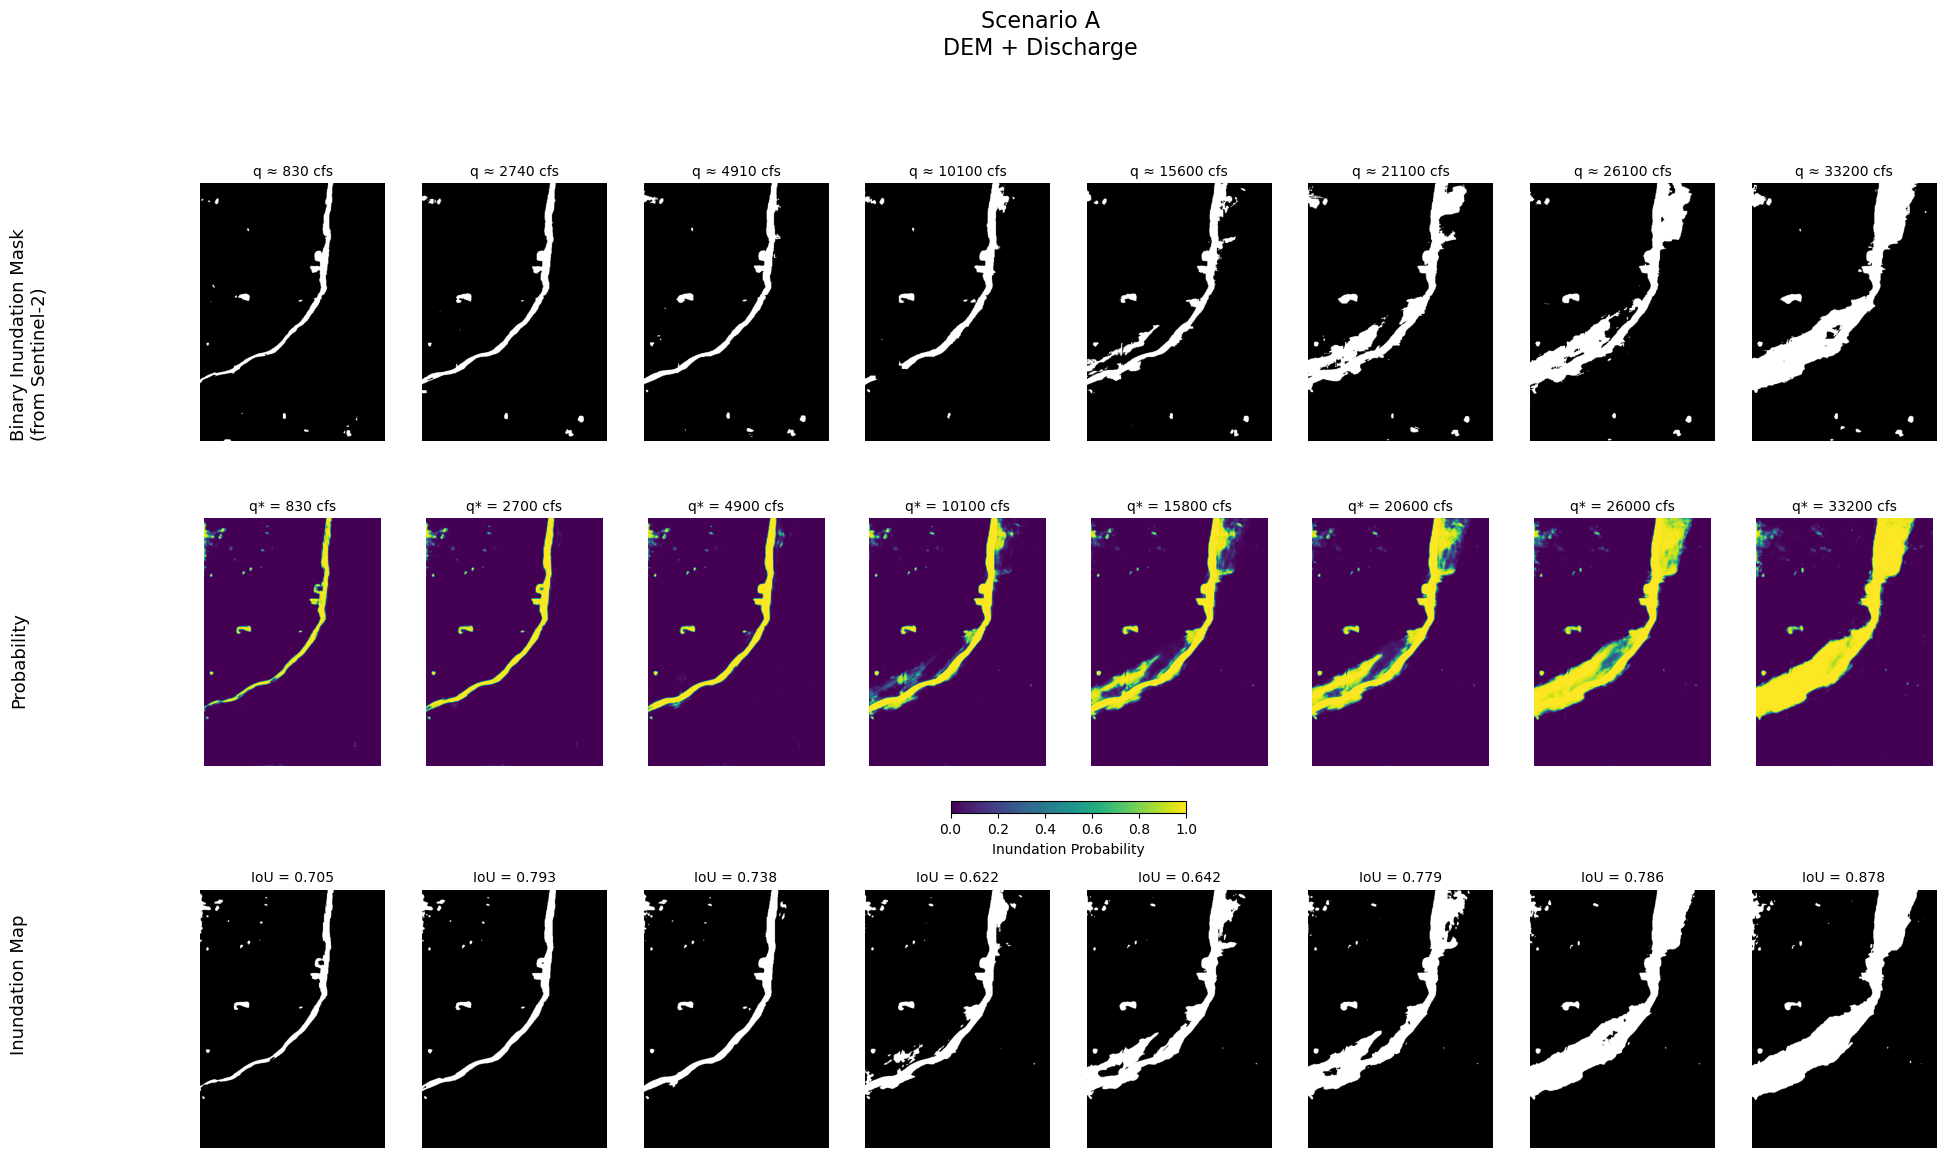

Scenario A IoU Summary: DEM + Discharge
----------------------------------------------------------------------
Scenario    Model inputs  Target discharge (cfs)  Closest observed discharge (cfs)   IoU
       A DEM + Discharge                     830                             830.0 0.705
       A DEM + Discharge                    2700                            2740.0 0.793
       A DEM + Discharge                    4900                            4910.0 0.738
       A DEM + Discharge                   10100                           10100.0 0.622
       A DEM + Discharge                   15800                           15600.0 0.642
       A DEM + Discharge                   20600                           21100.0 0.779
       A DEM + Discharge                   26000                           26100.0 0.786
       A DEM + Discharge                   33200                           33200.0 0.878


In [11]:
# ---------------------------------------------------
# 1) Choose which dataset to use
# ---------------------------------------------------
dates_all = read_dates_list("./03335500_data_folder/dates_all.txt")

all_ds = InundationDataset(
    dates_all,
    masks_dir,
    discharge_csv,
    static_dir
)

ds = all_ds
model.eval()

q_mu = getattr(ds, "q_mu", state["q_mu"])
q_std = getattr(ds, "q_std", state["q_std"])
thr = state.get("thr", 0.5)

target_qs = target_discharges

# ---------------------------------------------------
# 2) Precompute actual discharge values
# ---------------------------------------------------
Q_actual_list = []

for i in range(len(ds)):
    sample = ds[i]
    q_norm = sample["q"]
    q_scalar = float(q_norm.view(-1)[0])
    Q_actual = q_scalar * q_std + q_mu
    Q_actual_list.append(Q_actual)

Q_actual_arr = np.array(Q_actual_list)

# ---------------------------------------------------
# 3) Match target discharge, load predictions, compute IoU
# ---------------------------------------------------
selected = []

for q_target in target_qs:

    idx = int(np.argmin(np.abs(Q_actual_arr - q_target)))
    q_closest = Q_actual_arr[idx]

    sample = ds[idx]
    y_true = sample["y"].cpu().numpy()

    # Scenario-specific filenames
    if static_data_include == 1:
        season = None
        mask_path = f"predictions/option1_mask_{q_target}cfs.tif"
        prob_path = f"predictions/option1_prob_{q_target}cfs.tif"

    elif static_data_include == 2:
        season = q_to_season[q_target]
        mask_path = f"predictions/option2_mask_{q_target}cfs_{season}.tif"
        prob_path = f"predictions/option2_prob_{q_target}cfs_{season}.tif"

    else:
        raise ValueError("static_data_include must be 1 or 2.")

    if not os.path.exists(mask_path):
        raise FileNotFoundError(f"Missing mask file: {mask_path}")

    if not os.path.exists(prob_path):
        raise FileNotFoundError(f"Missing probability file: {prob_path}")

    with rasterio.open(mask_path) as src:
        pred_mask = src.read(1)

    with rasterio.open(prob_path) as src:
        prob_map = src.read(1)

    # IoU computation
    gt_bin = (y_true > 0.5).astype(np.uint8)
    pred_bin = (pred_mask > 0.5).astype(np.uint8)

    intersection = np.logical_and(gt_bin == 1, pred_bin == 1).sum()
    union = np.logical_or(gt_bin == 1, pred_bin == 1).sum()

    iou = np.nan if union == 0 else intersection / union

    selected.append({
        "q_target": q_target,
        "q_actual": float(q_closest),
        "idx": idx,
        "y_true": y_true,
        "prob_map": prob_map,
        "pred_mask": pred_mask,
        "iou": float(iou),
        "season": season,
    })

# ---------------------------------------------------
# 4) Plot: ground truth, probability, inundation map
# ---------------------------------------------------
n_events = len(selected)

fig, axes = plt.subplots(
    3,
    n_events,
    figsize=(2.8 * n_events, 13),
    sharex=True,
    sharey=True
)

if n_events == 1:
    axes = np.array([[axes[0]], [axes[1]], [axes[2]]])

for j, ev in enumerate(selected):

    if ev["season"] is None:
        title_top = f"q ≈ {ev['q_actual']:.0f} cfs"
    else:
        season_label = ev["season"].capitalize()
        title_top = f"q ≈ {ev['q_actual']:.0f} cfs\nSeason = {season_label}"

    # Ground truth
    ax_gt = axes[0, j]
    ax_gt.imshow(ev["y_true"], cmap="gray", vmin=0, vmax=1)
    ax_gt.set_title(title_top, fontsize=10)
    ax_gt.axis("off")

    # Probability map
    ax_prob = axes[1, j]
    im = ax_prob.imshow(ev["prob_map"], cmap="viridis", vmin=0, vmax=1)
    ax_prob.set_title(f"q* = {ev['q_target']} cfs", fontsize=10)
    ax_prob.axis("off")

    # Binary prediction
    ax_pred = axes[2, j]
    ax_pred.imshow(ev["pred_mask"], cmap="gray", vmin=0, vmax=1)
    ax_pred.set_title(f"IoU = {ev['iou']:.3f}", fontsize=10)
    ax_pred.axis("off")

# Row labels
fig.text(
    0.04, 0.75,
    "Binary Inundation Mask\n(from Sentinel-2)",
    va="center",
    rotation="vertical",
    fontsize=13
)

fig.text(
    0.04, 0.50,
    "Probability",
    va="center",
    rotation="vertical",
    fontsize=13
)

fig.text(
    0.04, 0.25,
    "Inundation Map",
    va="center",
    rotation="vertical",
    fontsize=13
)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=axes[1, :],
    orientation="horizontal",
    fraction=0.04,
    pad=0.12
)
cbar.set_label("Inundation Probability")

# Scenario title
if static_data_include == 1:
    scenario_title = "Scenario A\nDEM + Discharge"
elif static_data_include == 2:
    scenario_title = "Scenario B\nDEM + Discharge + Season"

fig.suptitle(scenario_title, fontsize=16, y=1.00)

#plt.tight_layout(rect=[0.06, 0.08, 1, 0.96])
plt.show()

# ---------------------------------------------------
# 5) Create and display Scenario A IoU summary
# ---------------------------------------------------
iou_scenario_a = pd.DataFrame([
    {
        "Scenario": "A",
        "Model inputs": "DEM + Discharge",
        "Target discharge (cfs)": ev["q_target"],
        "Closest observed discharge (cfs)": round(ev["q_actual"], 0),
        "IoU": round(ev["iou"], 3),
    }
    for ev in selected
])

iou_scenario_a = iou_scenario_a.sort_values("Target discharge (cfs)").reset_index(drop=True)

print("Scenario A IoU Summary: DEM + Discharge")
print("-" * 70)
print(iou_scenario_a.to_string(index=False))


## <span style="color:green">4.9 Scenario B: Option 2 — DEM + Discharge + Season</span>

In [13]:
# ---------------------------------------------------
# Scenario B setup: DEM + Discharge + Season
# ---------------------------------------------------
static_data_include = 2

cfg = options[static_data_include]

suffix = cfg["name"]
static_dir = cfg["static_dir"]
datetime_tag = cfg["datetime"]
base_ch = cfg["base_ch"]

ckpt_path = (
    f"./03335500_data_folder/checkpoints/unet_film_opt{static_data_include}_"
    f"base{base_ch}_{epochs_chosen}_{datetime_tag}.pt"
)

print("Loading Scenario B checkpoint:")
print(ckpt_path)

# Load Scenario B dataset
ds = InundationDataset(
    dates_all,
    masks_dir,
    discharge_csv,
    static_dir
)

# Load Scenario B checkpoint
state = torch.load(ckpt_path, map_location=device)

model = UNetFiLM(
    in_c=state["in_channels"],
    base=state["base"],
    cond_dim=state["cond_dim"]
).to(device)

model.load_state_dict(state["model"])
model.eval()

thr = state.get("thr", 0.5)

print("Scenario B model loaded successfully")
print("in_channels:", state["in_channels"])
print("base:", state["base"])
print("cond_dim:", state["cond_dim"])
print("threshold:", thr)

Loading Scenario B checkpoint:
./03335500_data_folder/checkpoints/unet_film_opt2_base64_100_20251203_175320.pt
Scenario B model loaded successfully
in_channels: 1
base: 64
cond_dim: 5
threshold: 0.6


/tmp/ipykernel_2060/3496524426.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


In [14]:
q_to_season = {
    830: "fall",
    2700: "summer",
    4900: "fall",
    10100: "winter",
    15800: "spring",
    20600: "summer",
    26000: "winter",
    33200: "spring",
}
target_qs = list(q_to_season.keys())
os.makedirs("predictions", exist_ok=True)

for q_star, season in q_to_season.items():
    prob, mask = predict_for_discharge(
        model=model,
        ds=ds,
        state=state,
        q_star=q_star,
        season=season,
        threshold=thr,
        device=device,
    )

    out_prob_path = f"predictions/option2_prob_{q_star}cfs_{season}.tif"
    out_mask_path = f"predictions/option2_mask_{q_star}cfs_{season}.tif"

    save_prediction(prob, mask, state, out_prob_path, out_mask_path)

Saved: predictions/option2_prob_830cfs_fall.tif
Saved: predictions/option2_mask_830cfs_fall.tif
Saved: predictions/option2_prob_2700cfs_summer.tif
Saved: predictions/option2_mask_2700cfs_summer.tif
Saved: predictions/option2_prob_4900cfs_fall.tif
Saved: predictions/option2_mask_4900cfs_fall.tif
Saved: predictions/option2_prob_10100cfs_winter.tif
Saved: predictions/option2_mask_10100cfs_winter.tif
Saved: predictions/option2_prob_15800cfs_spring.tif
Saved: predictions/option2_mask_15800cfs_spring.tif
Saved: predictions/option2_prob_20600cfs_summer.tif
Saved: predictions/option2_mask_20600cfs_summer.tif
Saved: predictions/option2_prob_26000cfs_winter.tif
Saved: predictions/option2_mask_26000cfs_winter.tif
Saved: predictions/option2_prob_33200cfs_spring.tif
Saved: predictions/option2_mask_33200cfs_spring.tif


## <span style="color:green">Visualize the predictions</span>

In [15]:
# ---------------------------------------------------
# 1) Choose which dataset to use
# ---------------------------------------------------
dates_all  = read_dates_list(f"dates_all.txt")
all_ds   = InundationDataset(dates_all,   masks_dir, discharge_csv, static_dir)
ds = all_ds        # or test_ds if you prefer
model.eval()

# De-normalization stats: prefer ds.q_mu/q_std if present
q_mu  = getattr(ds, "q_mu", state["q_mu"])
q_std = getattr(ds, "q_std", state["q_std"])

thr   = state["thr"]   # calibrated threshold



target_qs = list(q_to_season.keys())

# ---------------------------------------------------
# 2) Precompute actual discharge (cfs) for each sample in ds
# ---------------------------------------------------
Q_actual_list = []

for i in range(len(ds)):
    sample = ds[i]
    q_norm = sample["q"]                  # tensor, usually shape [1] or [D]
    q_scalar = float(q_norm.view(-1)[0])  # take first component if D>1
    Q_actual = q_scalar * q_std + q_mu    # de-normalize
    Q_actual_list.append(Q_actual)

Q_actual_arr = np.array(Q_actual_list)    # shape [N]

# ---------------------------------------------------
# 3) For each target_q, find closest index in ds & load predicted mask
# ---------------------------------------------------
selected = []  # list of dicts: {q_target, q_actual, idx, y_true, pred_mask, iou, season}

with torch.no_grad():
    for q_target in target_qs:
        season = q_to_season[q_target]
        season_label = season.capitalize()

        # index of closest discharge in this dataset
        idx = int(np.argmin(np.abs(Q_actual_arr - q_target)))
        q_closest = Q_actual_arr[idx]

        sample = ds[idx]
        y_true = sample["y"].cpu().numpy()          # [H,W]

        # Select correct file naming based on scenario
        if static_data_include == 1:
            mask_path = f"predictions/option1_mask_{q_target}cfs.tif"
            prob_path = f"predictions/option1_prob_{q_target}cfs.tif"
        
        elif static_data_include == 2:
            mask_path = f"predictions/option2_mask_{q_target}cfs_{season}.tif"
            prob_path = f"predictions/option2_prob_{q_target}cfs_{season}.tif"
        
        with rasterio.open(mask_path) as src:
            pred_mask = src.read(1)
        
        with rasterio.open(prob_path) as src:
            prob_map = src.read(1)
        
        # Load mask
        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Missing file: {mask_path}")
        with rasterio.open(mask_path) as src:
            pred_mask = src.read(1)  # [H,W], uint8 0/1

        # --------- IoU computation ----------
        gt_bin   = (y_true > 0.5).astype(np.uint8)
        pred_bin = (pred_mask > 0.5).astype(np.uint8)

        intersection = np.logical_and(gt_bin == 1, pred_bin == 1).sum()
        union        = np.logical_or(gt_bin == 1, pred_bin == 1).sum()

        if union == 0:
            iou = np.nan   # or 1.0 if you prefer treating all-zero as perfect
        else:
            iou = intersection / union
        # -----------------------------------

        selected.append({
            "q_target": q_target,
            "q_actual": float(q_closest),
            "idx": idx,
            "y_true": y_true,
            "prob_map": prob_map,
            "pred_mask": pred_mask,
            "iou": float(iou),
            "season": season,
        })

# ---------------------------------------------------
# Plot: ground truth on top, prediction on bottom
# ---------------------------------------------------
n_events = len(selected)

fig, axes = plt.subplots(
    3,
    n_events,
    figsize=(2.8 * n_events, 13),
    sharex=True,
    sharey=True
)

# Handle single column case
if n_events == 1:
    axes = np.array([[axes[0]], [axes[1]], [axes[2]]])

for j, ev in enumerate(selected):
    season_label = ev["season"].capitalize()

    # ---------- Ground Truth ----------
    ax_gt = axes[0, j]
    ax_gt.imshow(ev["y_true"], cmap="gray", vmin=0, vmax=1)
    ax_gt.set_title(
        f"q ≈ {ev['q_actual']:.0f} cfs\nSeason = {season_label}",
        fontsize=10
    )
    ax_gt.axis("off")

    # ---------- Probability ----------
    ax_prob = axes[1, j]
    im = ax_prob.imshow(ev["prob_map"], cmap="viridis", vmin=0, vmax=1)
    ax_prob.set_title(
        f"q* = {ev['q_target']} cfs",
        fontsize=10
    )
    ax_prob.axis("off")

    # ---------- Prediction ----------
    ax_pred = axes[2, j]
    ax_pred.imshow(ev["pred_mask"], cmap="gray", vmin=0, vmax=1)
    ax_pred.set_title(
        f"IoU = {ev['iou']:.3f}",
        fontsize=10
    )
    ax_pred.axis("off")

# ---------- Common row labels (cleaner than set_ylabel) ----------
fig.text(0.04, 0.75, "Binary Indunation Mask\n(from Sentinel-2)", va='center', rotation='vertical', fontsize=13)
fig.text(0.04, 0.50, "Probability", va='center', rotation='vertical', fontsize=13)
fig.text(0.04, 0.25, "Inundation Map", va='center', rotation='vertical', fontsize=13)

# ---------- Colorbar ----------
cbar = fig.colorbar(
    im,
    ax=axes[1, :],
    orientation="horizontal",
    fraction=0.04,
    pad=0.08
)
cbar.set_label("Inundation Probability")


# ---------- Super Title ----------
if static_data_include == 1:
    scenario_title = "Scenario A\nDEM + Discharge"
elif static_data_include == 2:
    scenario_title = "Scenario B\nDEM + Discharge + Season"

fig.suptitle(scenario_title, fontsize=16, y=1.00)

# ---------- Layout ----------
#plt.tight_layout(rect=[0.06, 0.08, 1, 0.95])

plt.show()

# ---------------------------------------------------
# Print IoU summary
# ---------------------------------------------------
iou_scenario_b = build_iou_table(
    selected,
    scenario_label="B",
    model_inputs="DEM + Discharge + Season"
)

print("Scenario B IoU Summary: DEM + Discharge + Season")
print("-" * 75)

print(iou_scenario_b.to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: 'dates_all.txt'


## <span style="color:green">4.10 IoU Comparison Across Discharge Scenarios</span>

In [ ]:
# ---------------------------------------------------
# Combine Scenario A and B IoU tables
# ---------------------------------------------------
iou_all = pd.concat(
    [iou_scenario_a, iou_scenario_b],
    ignore_index=True
)

iou_all = iou_all.sort_values(
    ["Target discharge (cfs)", "Scenario"]
).reset_index(drop=True)

#display(iou_all)

# ---------------------------------------------------
# Line plot: IoU vs discharge
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for scenario_name, group in iou_all.groupby("Scenario"):
    group = group.sort_values("Target discharge (cfs)")

    ax.plot(
        group["Target discharge (cfs)"],
        group["IoU"],
        marker="o",
        label=f"Scenario {scenario_name}"
    )

ax.set_xlabel("Discharge (cfs)")
ax.set_ylabel("IoU")
ax.set_title("IoU Comparison Across Discharge Scenarios")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# <span style="color:green">5. Discussion and Summary</span>

This study demonstrates a Spatial AI framework based on a FiLM-conditioned U-Net for rapid flood inundation mapping using remote sensing and hydrologic inputs. By integrating terrain information with discharge (and optionally season), the model effectively learns the relationship between flow conditions and flood extent without relying on computationally intensive hydrodynamic simulations. The framework produces high-resolution, probabilistic inundation maps and shows strong agreement with satellite-derived ground truth across a wide range of discharge conditions.

## <span style="color:green">Scenario A: DEM + Discharge</span>

Scenario A uses only terrain (DEM) and discharge as inputs. The results show:

- Consistent performance across discharges with IoU values ranging from 0.62 to 0.88
- Strong performance at higher discharges (e.g., 0.878 at 33,200 cfs), indicating the model effectively captures large-scale floodplain expansion
- Slightly lower performance at mid-range discharges (e.g., ~10,100–15,800 cfs), where flood extent transitions are more complex

Overall, Scenario A demonstrates that terrain and discharge alone are sufficient to capture the primary controls of inundation, making it a robust and generalizable baseline model.

## <span style="color:green">Scenario B: DEM + Discharge + Season</span>

Scenario B incorporates seasonal information in addition to terrain and discharge. The results show:

- Systematic improvement over Scenario A, with IoU values reaching up to 0.896
- Notable gains at lower and moderate discharges (e.g., 0.806 vs 0.705 at 830 cfs, 0.896 vs 0.793 at 2700 cfs)
- Improved representation of seasonal hydrologic variability such as snowmelt, vegetation, and antecedent moisture conditions

However, improvements are not uniform across all discharges (e.g., similar performance at ~15,800–20,600 cfs), suggesting that seasonal effects are more influential under certain flow regimes.

## <span style="color:green">Overall Insights</span>
- Adding seasonal conditioning enhances model performance, particularly for low-to-moderate flood events
- The FiLM-based conditioning enables the model to adapt dynamically to different hydrologic contexts
- Both scenarios achieve high IoU values, confirming that the framework is capable of learning physically meaningful inundation patterns from data
<span style="color:green">Final Takeaway</span>

The proposed framework provides a scalable, data-driven alternative to traditional flood modeling, with:

Scenario A offering simplicity and generalizability
Scenario B offering improved accuracy through additional environmental context

Together, these results highlight the potential of Spatial AI for fast, reliable, and reusable flood inundation mapping across diverse conditions.

## <span style="color:green">Final Takeaway</span>

The proposed framework provides a scalable, data-driven alternative to traditional flood modeling, with:

- Scenario A offering simplicity and generalizability
- Scenario B offering improved accuracy through additional environmental context

Together, these results highlight the potential of Spatial AI for fast, reliable, and reusable flood inundation mapping across diverse conditions.